# Digital Service Engagement & Churn Prediction: Production-Grade Analytics for Government Platforms

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** User engagement and service retention analytics for government digital platforms

---

This notebook builds a production-oriented churn prediction system framed around government digital service platforms. While using a telco customer dataset as a proxy, the analysis targets Australian government contexts — myGov, myHealth Record, myTax, and other citizen-facing digital services managed by Services Australia and the DTA.

**Why digital service engagement matters for government:**
- myGov has 25+ million active accounts — Australia's largest digital platform
- The DTA's Digital Experience Policy mandates user-centred service design
- Service abandonment increases call centre load ($12-25 per call vs $0.20 per digital transaction)
- Digital inclusion is a policy priority — understanding *why* users disengage helps target support
- The 2025 Data and Digital Government Strategy sets targets for digital service adoption

**What makes government churn prediction different from commercial:**
- Government services are often **mandatory** — citizens can't truly "churn" from Centrelink
- "Churn" means **reverting to costly channels** (phone, in-person) rather than leaving entirely
- **Digital inclusion** is a goal, not just efficiency — vulnerable populations need extra support
- **Accessibility requirements** (WCAG 2.1 AA) mean the platform must work for everyone
- Success is measured in **citizen satisfaction** (CSS), not revenue

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Disengagement Risk Profile Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
import os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.base import clone

plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11})
COLOR_RETAINED = '#2ecc71'
COLOR_CHURNED = '#e74c3c'
print("Libraries loaded.")

Libraries loaded.


---
## 1. Data Loading & Initial Assessment

The Telco Customer Churn dataset maps to government digital services:

| Telco Feature | Government Digital Service Equivalent |
|---------------|--------------------------------------|
| tenure (months) | Time since myGov account creation |
| Contract type | Service tier (basic myGov vs linked services) |
| Internet/Phone services | Digital channels used (app, web, phone) |
| Online Security/Backup | Linked services (myHealth, myTax, Medicare) |
| Monthly/Total Charges | Transaction volume / service usage intensity |
| Tech Support | Help desk / assisted digital interactions |
| Paperless Billing | Digital communication preference |
| Churn | Reverted to non-digital channel (phone/in-person) |

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break
if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','
df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: 7,043 rows × 21 columns


In [3]:
# Schema overview
print("=" * 70)
print("SCHEMA OVERVIEW")
print("=" * 70)
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<10} unique={df[col].nunique():<8} nulls={df[col].isnull().sum()}")
df.head()

SCHEMA OVERVIEW
  customerID                object     unique=7043     nulls=0
  gender                    object     unique=2        nulls=0
  SeniorCitizen             int64      unique=2        nulls=0
  Partner                   object     unique=2        nulls=0
  Dependents                object     unique=2        nulls=0
  tenure                    int64      unique=73       nulls=0
  PhoneService              object     unique=2        nulls=0
  MultipleLines             object     unique=3        nulls=0
  InternetService           object     unique=3        nulls=0
  OnlineSecurity            object     unique=3        nulls=0
  OnlineBackup              object     unique=3        nulls=0
  DeviceProtection          object     unique=3        nulls=0
  TechSupport               object     unique=3        nulls=0
  StreamingTV               object     unique=3        nulls=0
  StreamingMovies           object     unique=3        nulls=0
  Contract                  object     

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Identify target
target_col = None
for col in df.columns:
    if 'churn' in col.lower():
        target_col = col
        break
if target_col is None:
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() == 2:
            target_col = col; break

print(f"Target: {target_col}")
print(f"Values: {df[target_col].value_counts().to_dict()}")

class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
majority_count = class_counts[majority_class]
minority_count = class_counts[minority_class]
churn_pct = minority_count / len(df) * 100

print(f"\nRetained ({majority_class}): {majority_count:,} ({majority_count/len(df)*100:.1f}%)")
print(f"Churned  ({minority_class}): {minority_count:,} ({churn_pct:.1f}%)")
print(f"\nIn government context: ~{churn_pct:.0f}% of users revert to non-digital channels.")
print(f"Each reverted user costs ~$12-25/interaction in call centre load vs $0.20 digital.")

Target: Churn
Values: {'No': 5174, 'Yes': 1869}

Retained (No): 5,174 (73.5%)
Churned  (Yes): 1,869 (26.5%)

In government context: ~27% of users revert to non-digital channels.
Each reverted user costs ~$12-25/interaction in call centre load vs $0.20 digital.


---
## 2. Exploratory Data Analysis

Government digital service EDA focuses on understanding which user segments are most likely to disengage. This informs the DTA's Digital Inclusion Strategy and Services Australia's channel management approach.

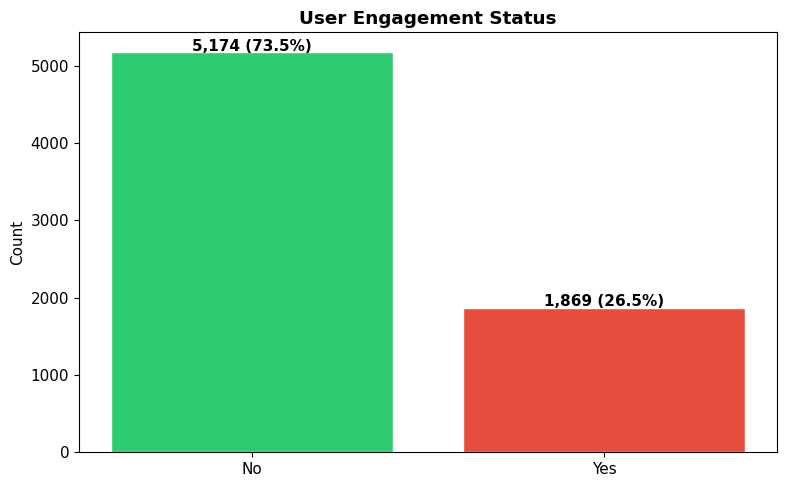

In [5]:
# 2.1 Churn distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLOR_RETAINED, COLOR_CHURNED]
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white')
ax.set_title('User Engagement Status', fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{count:,} ({count/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

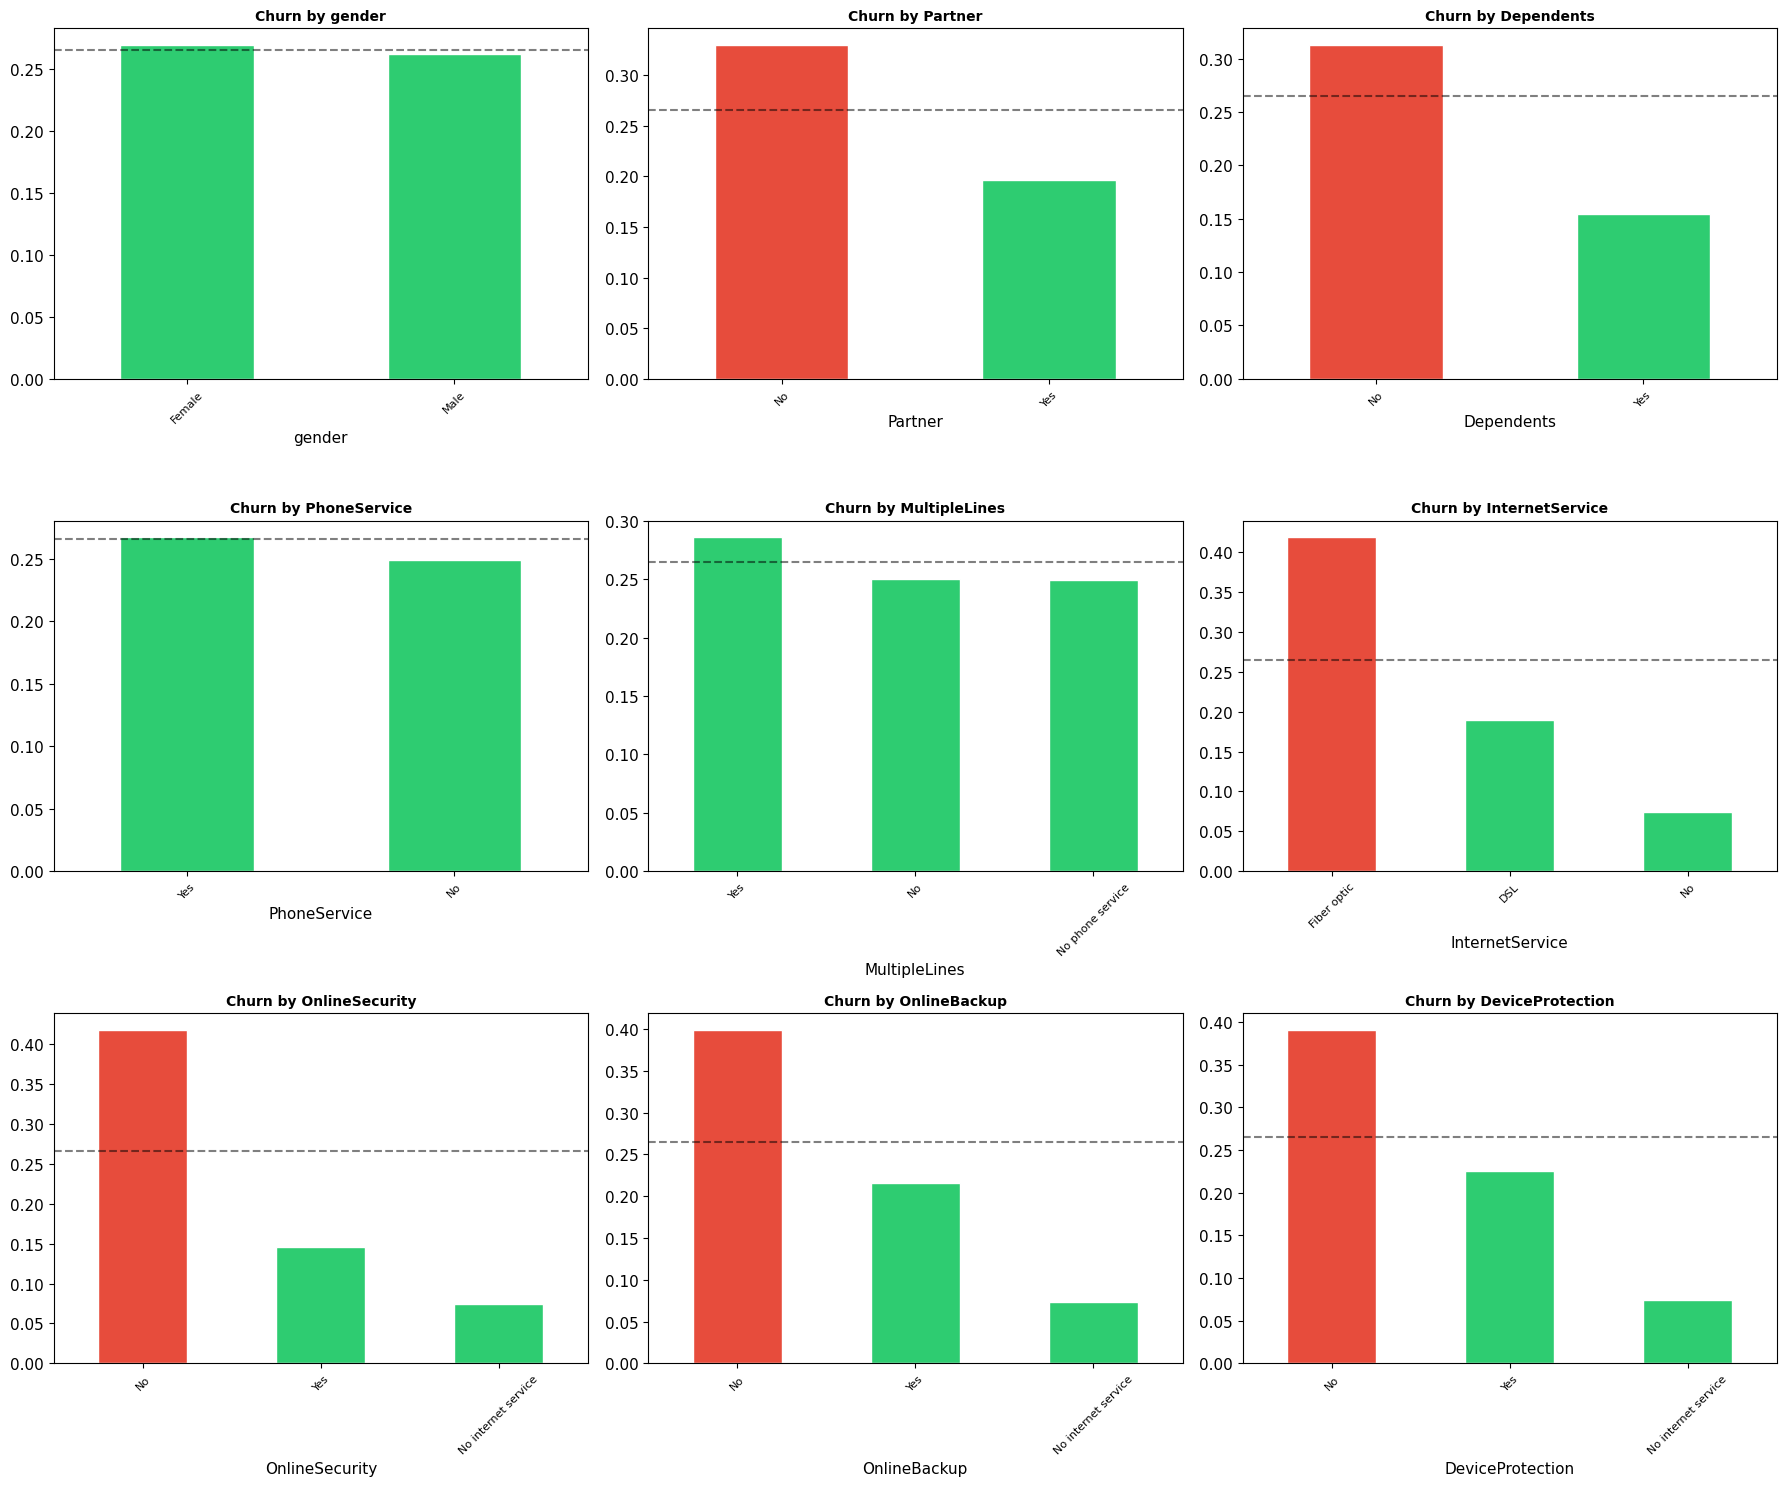

In [6]:
# 2.2 Categorical features — churn rate
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() <= 10]

n_cats = min(len(cat_cols), 9)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        cr = df.groupby(col)[target_col].apply(lambda x: (x == minority_class).mean()).sort_values(ascending=False)
        colors = [COLOR_CHURNED if r > churn_pct/100*1.1 else COLOR_RETAINED for r in cr.values]
        cr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Churn by {col}', fontweight='bold', fontsize=10)
        ax.axhline(y=churn_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

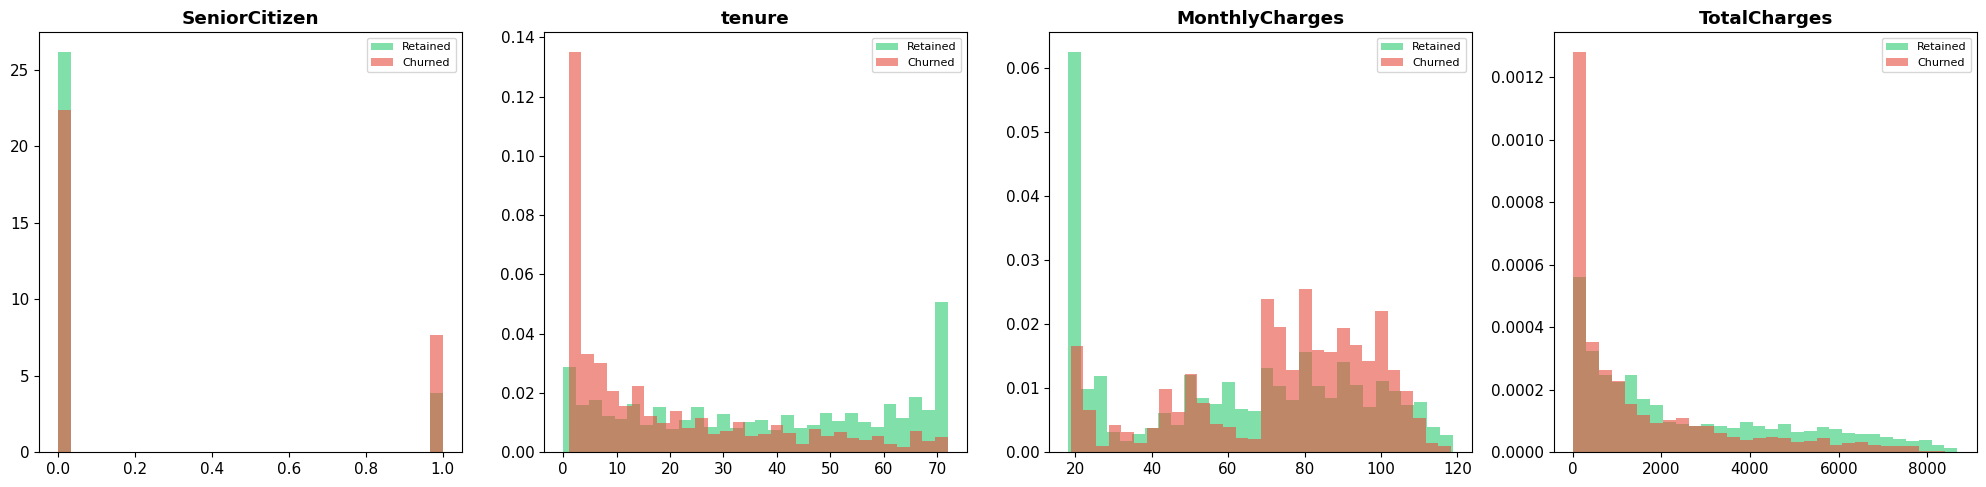

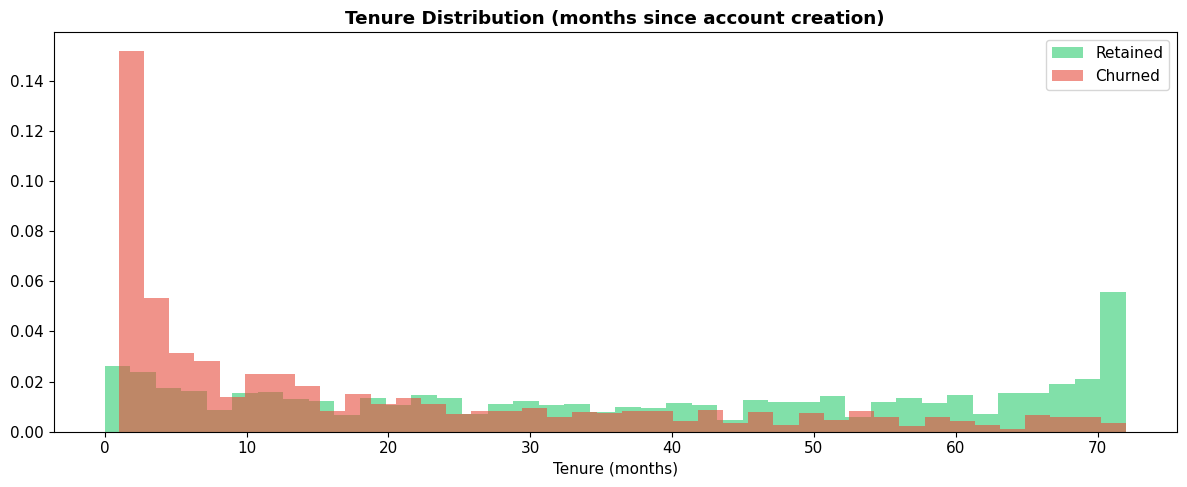

Churned users have shorter tenure on average:
  Retained: 37.6 months
  Churned:  18.0 months


In [7]:
# 2.3 Numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

# Fix TotalCharges if it's object type
if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

n_plot = min(len(num_cols), 4)
if n_plot > 0:
    fig, axes = plt.subplots(1, n_plot, figsize=(5*n_plot, 5))
    if n_plot == 1: axes = [axes]
    for idx, col in enumerate(num_cols[:n_plot]):
        ax = axes[idx]
        for cls, color, label in [(majority_class, COLOR_RETAINED, 'Retained'),
                                   (minority_class, COLOR_CHURNED, 'Churned')]:
            subset = df[df[target_col] == cls][col].dropna()
            ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Tenure analysis
tenure_col = [c for c in df.columns if 'tenure' in c.lower()]
if tenure_col:
    fig, ax = plt.subplots(figsize=(12, 5))
    for cls, color, label in [(majority_class, COLOR_RETAINED, 'Retained'),
                               (minority_class, COLOR_CHURNED, 'Churned')]:
        subset = df[df[target_col] == cls][tenure_col[0]].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title('Tenure Distribution (months since account creation)', fontweight='bold')
    ax.set_xlabel('Tenure (months)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Churned users have shorter tenure on average:")
    print(f"  Retained: {df[df[target_col]==majority_class][tenure_col[0]].mean():.1f} months")
    print(f"  Churned:  {df[df[target_col]==minority_class][tenure_col[0]].mean():.1f} months")

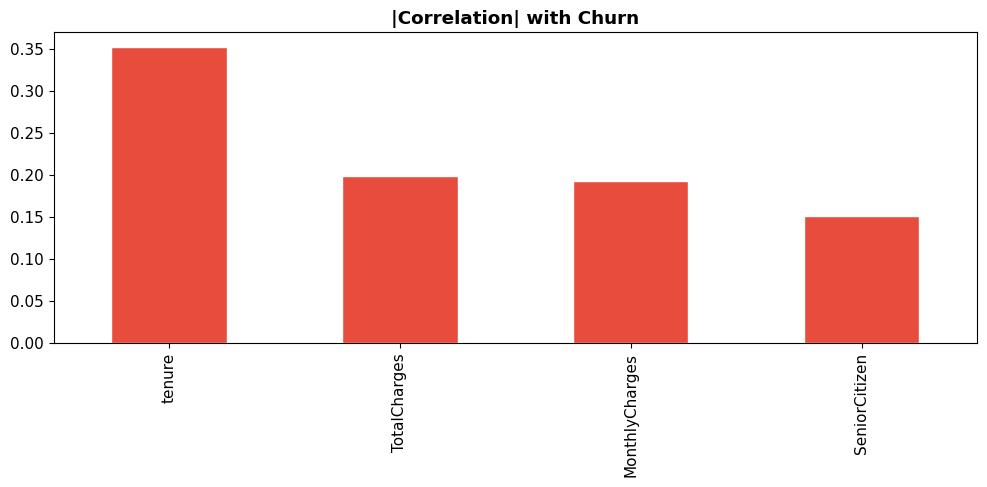

In [8]:
# 2.4 Correlation
target_binary = (df[target_col] == minority_class).astype(int)
if num_cols:
    corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    corr.plot(kind='bar', ax=ax, color=[COLOR_CHURNED if c > 0.1 else '#95a5a6' for c in corr.values], edgecolor='white')
    ax.set_title('|Correlation| with Churn', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. Feature Engineering & Preprocessing

Government digital service features map to:
- **Tenure** → account age, early-stage users need onboarding support
- **Contract** → service commitment level (linked services act as retention)
- **Services used** → digital service breadth (myTax + Medicare + myHealth = high engagement)
- **Charges** → transaction volume / usage intensity
- **Support interactions** → help desk calls, assisted digital sessions

In [9]:
# 3.1 Feature engineering
df_feat = df.copy()

# Fix TotalCharges
if 'TotalCharges' in df_feat.columns:
    df_feat['TotalCharges'] = pd.to_numeric(df_feat['TotalCharges'], errors='coerce')

# Drop customerID
id_cols = [c for c in df_feat.columns if 'customerid' in c.lower() or 'id' == c.lower()]
df_feat.drop(columns=[c for c in id_cols if c in df_feat.columns], inplace=True, errors='ignore')

# Services count — how many services the user has
service_cols = [c for c in df_feat.columns if df_feat[c].dtype == 'object' and c != target_col
                and set(df_feat[c].dropna().unique()) & {'Yes', 'No', 'No internet service', 'No phone service'}]
if service_cols:
    df_feat['n_services'] = df_feat[service_cols].apply(
        lambda row: sum(1 for v in row if str(v) == 'Yes'), axis=1)
    print(f"  Created n_services from {len(service_cols)} service columns")

# Average monthly charge per tenure month
if 'tenure' in df_feat.columns and 'MonthlyCharges' in df_feat.columns:
    df_feat['charge_tenure_ratio'] = df_feat['MonthlyCharges'] / df_feat['tenure'].clip(lower=1)
    
if 'TotalCharges' in df_feat.columns and 'MonthlyCharges' in df_feat.columns:
    df_feat['charge_consistency'] = df_feat['TotalCharges'] / (df_feat['MonthlyCharges'].clip(lower=1) * df_feat.get('tenure', pd.Series([1]*len(df_feat))).clip(lower=1))

# Tenure buckets
if 'tenure' in df_feat.columns:
    df_feat['tenure_log'] = np.log1p(df_feat['tenure'])
    df_feat['is_new_user'] = (df_feat['tenure'] <= 6).astype(int)
    df_feat['is_long_term'] = (df_feat['tenure'] >= 48).astype(int)

# Log charges
for col in ['MonthlyCharges', 'TotalCharges']:
    if col in df_feat.columns:
        df_feat[f'{col}_log'] = np.log1p(df_feat[col].fillna(0))

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"Engineered {len(new_features)} features: {new_features}")

  Created n_services from 12 service columns
Engineered 8 features: ['n_services', 'charge_tenure_ratio', 'charge_consistency', 'tenure_log', 'is_new_user', 'is_long_term', 'MonthlyCharges_log', 'TotalCharges_log']


In [10]:
# 3.2 Encode and prepare
label_encoders = {}
cat_feature_cols = [c for c in df_feat.select_dtypes(include=['object']).columns if c != target_col]
for col in cat_feature_cols:
    le = LabelEncoder()
    df_feat[col + '_enc'] = le.fit_transform(df_feat[col].fillna('MISSING').astype(str))
    label_encoders[col] = le

drop_cols = [target_col] + cat_feature_cols
feature_cols = [c for c in df_feat.columns if c not in drop_cols
                and df_feat[c].dtype in ['int64', 'float64']]

df_feat[feature_cols] = df_feat[feature_cols].fillna(df_feat[feature_cols].median())
y = (df_feat[target_col] == minority_class).astype(int).values
X = StandardScaler().fit_transform(df_feat[feature_cols])

print(f"X={X.shape}, y={y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

X=(7043, 27), y=(7043,)
Churn rate: 26.5%

Features (27):
  [ 0] SeniorCitizen
  [ 1] tenure
  [ 2] MonthlyCharges
  [ 3] TotalCharges
  [ 4] n_services
  [ 5] charge_tenure_ratio
  [ 6] charge_consistency
  [ 7] tenure_log
  [ 8] is_new_user
  [ 9] is_long_term
  [10] MonthlyCharges_log
  [11] TotalCharges_log
  [12] gender_enc
  [13] Partner_enc
  [14] Dependents_enc
  [15] PhoneService_enc
  [16] MultipleLines_enc
  [17] InternetService_enc
  [18] OnlineSecurity_enc
  [19] OnlineBackup_enc
  [20] DeviceProtection_enc
  [21] TechSupport_enc
  [22] StreamingTV_enc
  [23] StreamingMovies_enc
  [24] Contract_enc
  [25] PaperlessBilling_enc
  [26] PaymentMethod_enc


---
## 4. Disengagement Risk Profile Analysis

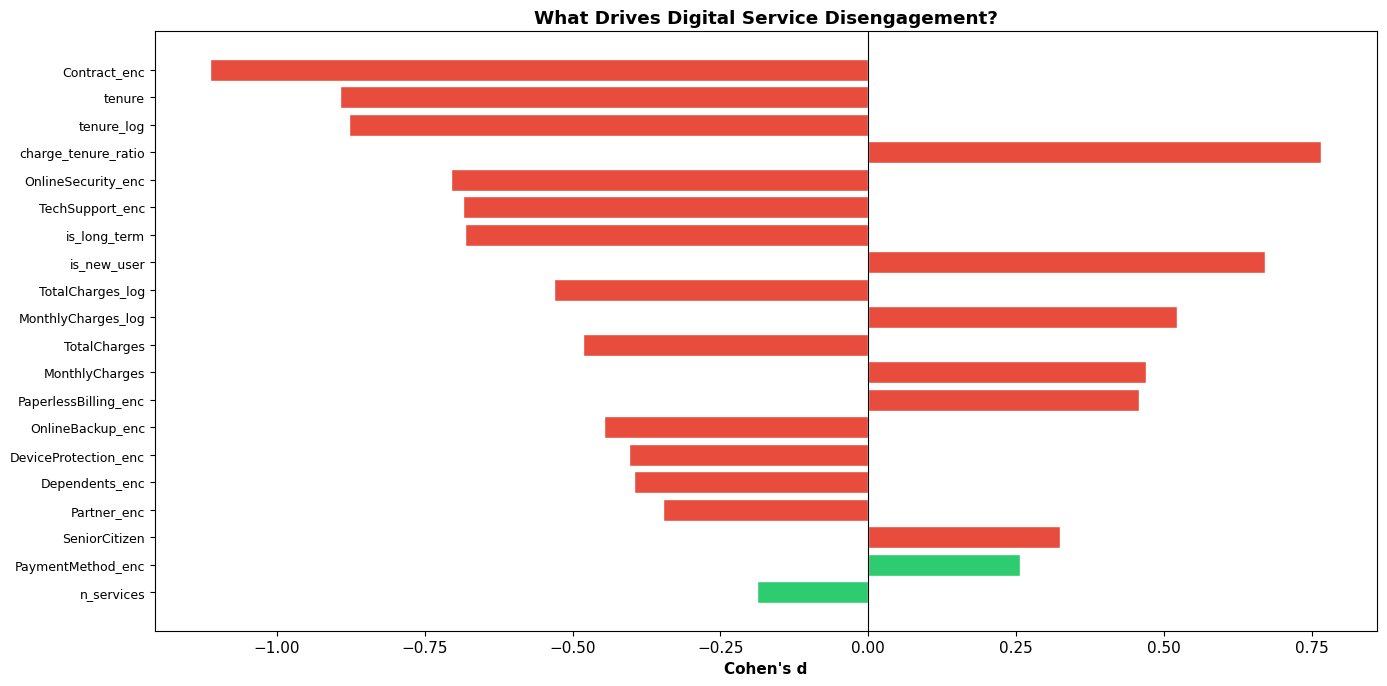

Top disengagement drivers:
  Contract_enc                   d=-1.112
  tenure                         d=-0.893
  tenure_log                     d=-0.879
  charge_tenure_ratio            d=+0.766
  OnlineSecurity_enc             d=-0.706
  TechSupport_enc                d=-0.685
  is_long_term                   d=-0.682
  is_new_user                    d=+0.671


In [11]:
# Cohen's d
cohens_d = {}
for i, col in enumerate(feature_cols):
    ok = X[y==0, i]; ch = X[y==1, i]
    ps = np.sqrt((ok.std()**2 + ch.std()**2)/2)
    cohens_d[col] = (ch.mean() - ok.mean()) / ps if ps > 0 else 0

sorted_effects = sorted(cohens_d.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, max(6, min(20, len(sorted_effects))*0.35)))
feats = [x[0] for x in sorted_effects[:20]]; vals = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_CHURNED if abs(d)>0.3 else COLOR_RETAINED if abs(d)>0.15 else '#bdc3c7' for d in vals]
ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel("Cohen's d", fontweight='bold')
ax.set_title("What Drives Digital Service Disengagement?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

print("Top disengagement drivers:")
for f, d in sorted_effects[:8]:
    print(f"  {f:30s} d={d:+.3f}")

---
## 5. Model Training & Comparison

In [12]:
n_ch = y.sum(); n_ret = (1-y).sum(); sr = n_ret/n_ch
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=10),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=sr, random_state=42, eval_metric='logloss', max_depth=6, learning_rate=0.1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0)
}
print(f"Ratio: 1:{sr:.1f} | Samples: {len(X):,} | Features: {X.shape[1]}")

Ratio: 1:2.8 | Samples: 7,043 | Features: 27


In [13]:
# CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}; oof_preds = {}; oof_probs = {}

for mn, mt in models.items():
    print(f"\n{'='*60}\n{mn}\n{'='*60}")
    op = np.zeros(len(y), dtype=int); ob = np.zeros(len(y)); t0 = time.time()
    for fold, (tri, vai) in enumerate(skf.split(X, y)):
        m = clone(mt); m.fit(X[tri], y[tri])
        op[vai] = m.predict(X[vai]); ob[vai] = m.predict_proba(X[vai])[:, 1]
        print(f"  Fold {fold+1}: F1={f1_score(y[vai],op[vai]):.4f} | PR-AUC={average_precision_score(y[vai],ob[vai]):.4f}")
    elapsed = time.time() - t0
    results[mn] = {'accuracy': accuracy_score(y,op), 'precision': precision_score(y,op,zero_division=0),
                    'recall': recall_score(y,op,zero_division=0), 'f1': f1_score(y,op,zero_division=0),
                    'roc_auc': roc_auc_score(y,ob), 'pr_auc': average_precision_score(y,ob),
                    'brier': brier_score_loss(y,ob), 'time': elapsed}
    oof_preds[mn] = op; oof_probs[mn] = ob
    r = results[mn]
    print(f"  OOF: F1={r['f1']:.4f} | PR-AUC={r['pr_auc']:.4f} | ROC-AUC={r['roc_auc']:.4f}")


Logistic Regression
  Fold 1: F1=0.6281 | PR-AUC=0.6896
  Fold 2: F1=0.6324 | PR-AUC=0.6502
  Fold 3: F1=0.6244 | PR-AUC=0.6658
  OOF: F1=0.6283 | PR-AUC=0.6659 | ROC-AUC=0.8470

Random Forest
  Fold 1: F1=0.6381 | PR-AUC=0.6727
  Fold 2: F1=0.6259 | PR-AUC=0.6339
  Fold 3: F1=0.6093 | PR-AUC=0.6453
  OOF: F1=0.6246 | PR-AUC=0.6473 | ROC-AUC=0.8395

XGBoost
  Fold 1: F1=0.6300 | PR-AUC=0.6634
  Fold 2: F1=0.6334 | PR-AUC=0.6254
  Fold 3: F1=0.6091 | PR-AUC=0.6288
  OOF: F1=0.6243 | PR-AUC=0.6377 | ROC-AUC=0.8350

LightGBM
  Fold 1: F1=0.6360 | PR-AUC=0.6897
  Fold 2: F1=0.6366 | PR-AUC=0.6422
  Fold 3: F1=0.6123 | PR-AUC=0.6471
  OOF: F1=0.6285 | PR-AUC=0.6559 | ROC-AUC=0.8426


In [14]:
# Results
print("\n" + "="*95 + "\nMODEL COMPARISON\n" + "="*95)
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'ROC':>7} {'PR-AUC':>7} {'Brier':>7}")
print("-"*95)
for n, r in results.items():
    print(f"{n:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f} {r['pr_auc']:>7.4f} {r['brier']:>7.4f}")
best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest: {best_model[0]} (PR-AUC={best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON
Model                      Acc    Prec  Recall      F1     ROC  PR-AUC   Brier
-----------------------------------------------------------------------------------------------
Logistic Regression     0.7522  0.5219  0.7892  0.6283  0.8470  0.6659  0.1630
Random Forest           0.7821  0.5752  0.6833  0.6246  0.8395  0.6473  0.1463
XGBoost                 0.7669  0.5454  0.7298  0.6243  0.8350  0.6377  0.1567
LightGBM                0.7622  0.5367  0.7582  0.6285  0.8426  0.6559  0.1568

Best: Logistic Regression (PR-AUC=0.6659)


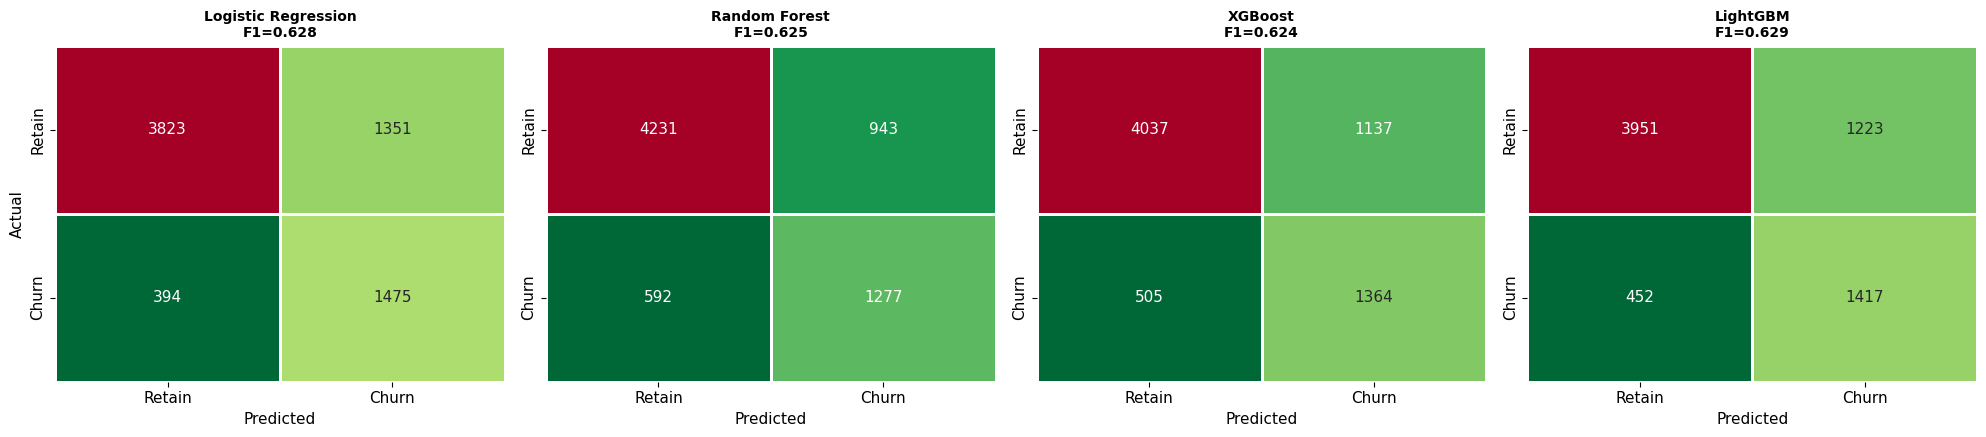

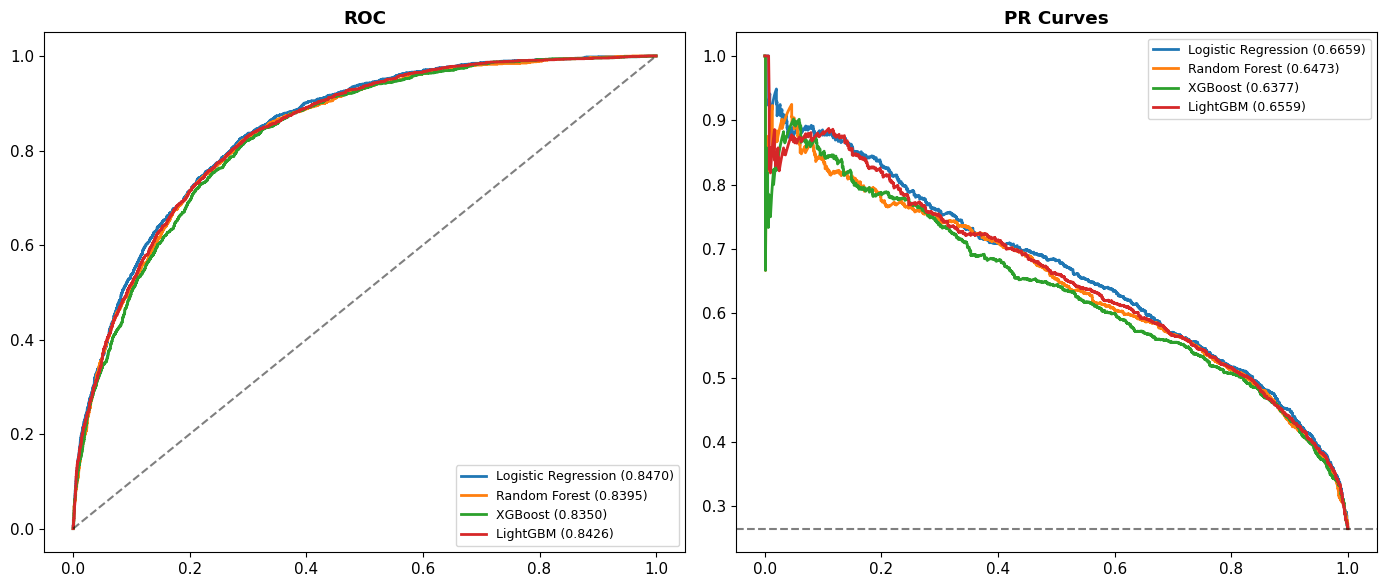

In [15]:
# Confusion matrices + curves
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, (n, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['Retain', 'Churn'], yticklabels=['Retain', 'Churn'], cbar=False, linewidths=1)
    axes[idx].set_title(f'{n}\nF1={results[n]["f1"]:.3f}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx==0 else ''); axes[idx].set_xlabel('Predicted')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for n, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob); axes[0].plot(fpr, tpr, label=f"{n} ({results[n]['roc_auc']:.4f})", linewidth=2)
    prec, rec, _ = precision_recall_curve(y, prob); axes[1].plot(rec, prec, label=f"{n} ({results[n]['pr_auc']:.4f})", linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('ROC', fontweight='bold'); axes[0].legend(fontsize=9)
axes[1].axhline(y=y.mean(),color='k',linestyle='--',alpha=0.5); axes[1].set_title('PR Curves', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

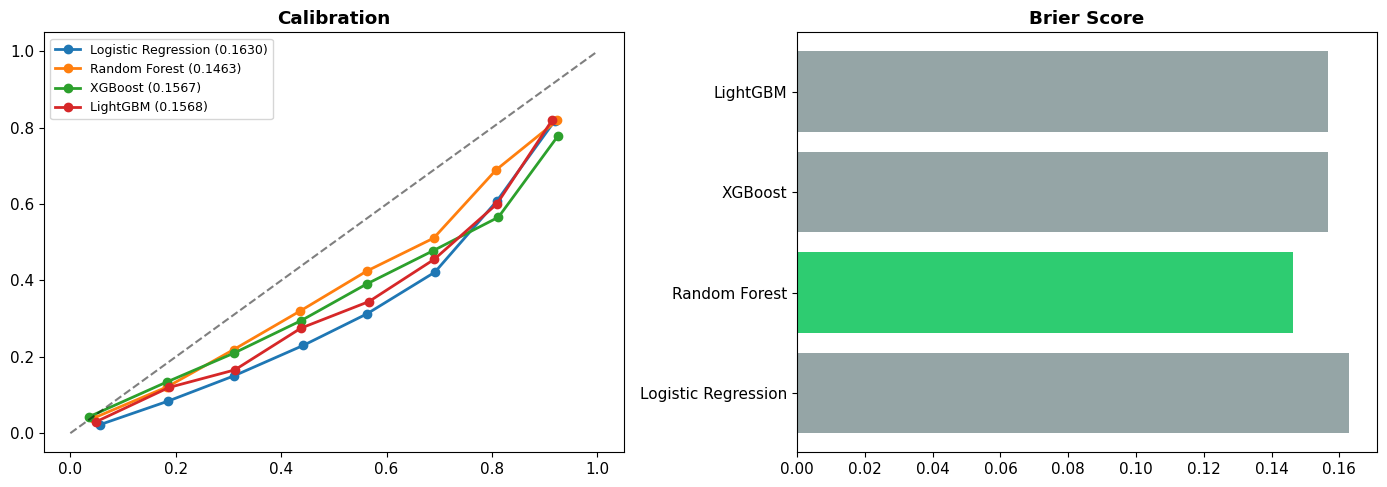

In [16]:
# Calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n, prob in oof_probs.items():
    pt, pp = calibration_curve(y, prob, n_bins=8, strategy='uniform')
    axes[0].plot(pp, pt, marker='o', label=f"{n} ({results[n]['brier']:.4f})", linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('Calibration', fontweight='bold'); axes[0].legend(fontsize=9)
brier = [results[n]['brier'] for n in results]
axes[1].barh(list(results.keys()), brier, color=[COLOR_RETAINED if b==min(brier) else '#95a5a6' for b in brier])
axes[1].set_title('Brier Score', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

In government digital services, the cost calculation differs from commercial:

| Outcome | Government Impact |
|---------|------------------|
| **FP** (wrongly flagged as at-risk) | Unnecessary outreach — low cost, minimal harm |
| **FN** (missed at-risk user) | User reverts to phone/in-person — $12-25/interaction vs $0.20 digital |
| **TP** (correctly identified at-risk) | Targeted intervention — onboarding help, accessibility support |

Unlike commercial churn, false positives in government are **low cost** — proactive outreach to an engaged user is harmless. This means we can afford **lower thresholds** (higher recall) than in commercial settings.

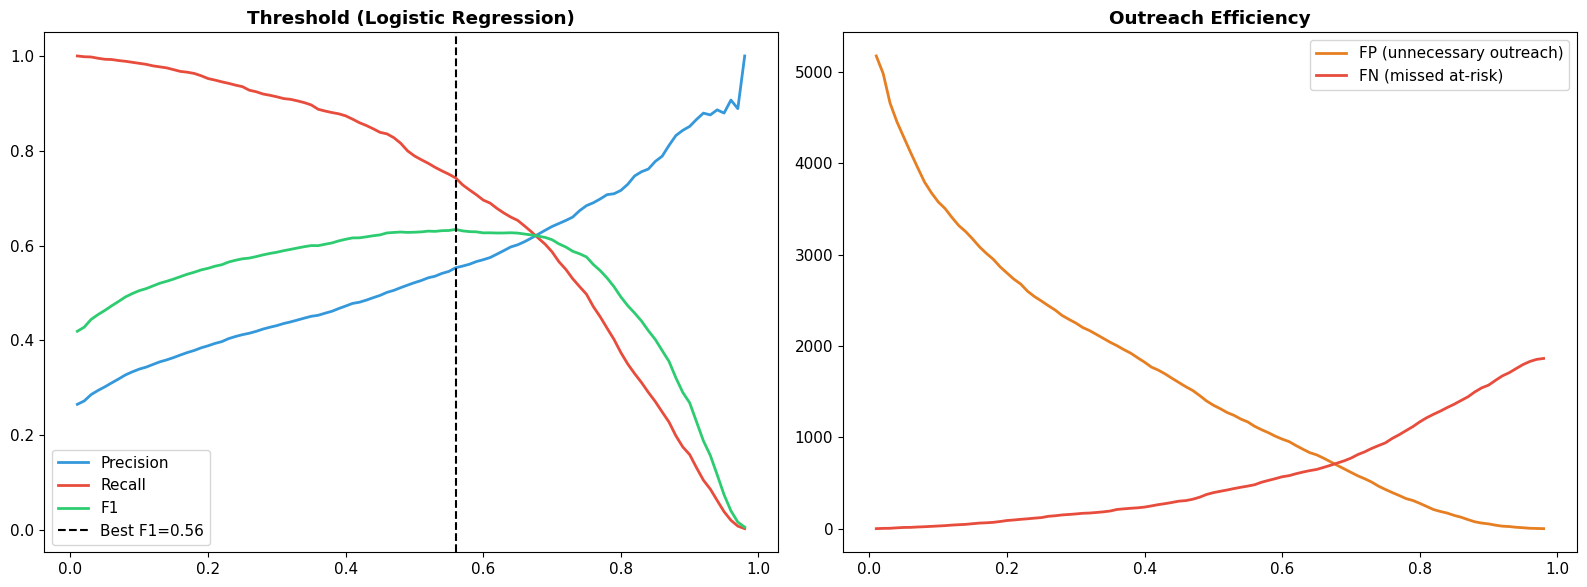

In [17]:
best_name = best_model[0]; best_prob = oof_probs[best_name]
thr_results = []
for t in np.arange(0.01, 0.99, 0.01):
    pt = (best_prob >= t).astype(int)
    tp=((pt==1)&(y==1)).sum(); fp=((pt==1)&(y==0)).sum(); fn=((pt==0)&(y==1)).sum()
    p=tp/(tp+fp) if (tp+fp)>0 else 0; r=tp/(tp+fn) if (tp+fn)>0 else 0
    f=2*p*r/(p+r) if (p+r)>0 else 0
    thr_results.append({'threshold':t,'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn})
thr_df = pd.DataFrame(thr_results)
best_f1_idx = thr_df['f1'].idxmax(); best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_CHURNED, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_RETAINED, label='F1', linewidth=2)
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', label=f'Best F1={best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold ({best_name})', fontweight='bold'); axes[0].legend()
axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='FP (unnecessary outreach)', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_CHURNED, label='FN (missed at-risk)', linewidth=2)
axes[1].set_title('Outreach Efficiency', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

In [18]:
# Cost scenarios
COST_FN = 200    # Lost digital user: 10+ phone calls/year × $20/call average
COST_FP = 5      # Proactive outreach to engaged user: email/notification
COST_TP = 20     # Successful retention intervention

scenarios = {
    'Proactive outreach (low thresh)': 0.20,
    'Balanced (Best F1)': best_f1_thresh,
    'Targeted intervention': 0.50,
    'High-confidence only': 0.70,
}
print("=" * 90)
print("DIGITAL SERVICE RETENTION SCENARIOS")
print("=" * 90)
print(f"\n{'Scenario':<40} {'Thresh':>6} {'Recall':>7} {'Prec':>7} {'FP':>6} {'FN':>5} {'Cost':>10}")
print("-" * 90)
for name, thresh in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold']-thresh).abs().argsort()[:1]].iloc[0]
    total = row['fn']*COST_FN + row['fp']*COST_FP + row['tp']*COST_TP
    print(f"{name:<40} {thresh:>6.2f} {row['recall']:>7.4f} {row['precision']:>7.4f} "
          f"{int(row['fp']):>6,} {int(row['fn']):>5,} ${total:>8,.0f}")
print(f"\nGovernment insight: FP cost is very low (just an email), so lower thresholds")
print(f"are optimal — cast a wide net and provide proactive digital support.")

DIGITAL SERVICE RETENTION SCENARIOS

Scenario                                 Thresh  Recall    Prec     FP    FN       Cost
------------------------------------------------------------------------------------------
Proactive outreach (low thresh)            0.20  0.9524  0.3888  2,798    89 $  67,390
Balanced (Best F1)                         0.56  0.7426  0.5534  1,120   481 $ 129,560
Targeted intervention                      0.50  0.7892  0.5219  1,351   394 $ 115,055
High-confidence only                       0.70  0.5869  0.6404    616   772 $ 179,420

Government insight: FP cost is very low (just an email), so lower thresholds
are optimal — cast a wide net and provide proactive digital support.


---
## 7. Model Interpretability

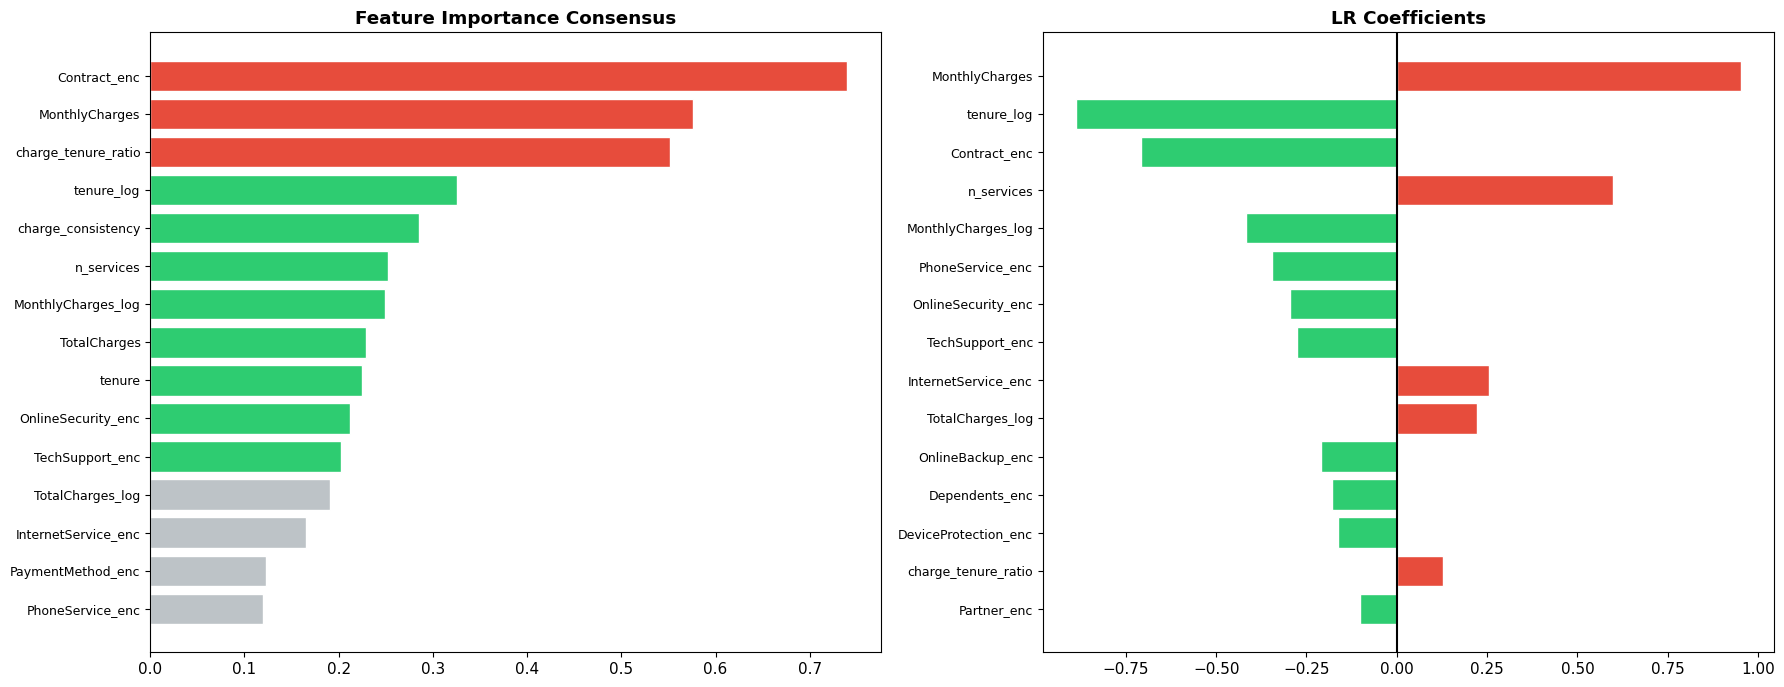

Top 5 churn drivers:
  [1] Contract_enc (0.739)
  [2] MonthlyCharges (0.576)
  [3] charge_tenure_ratio (0.552)
  [4] tenure_log (0.326)
  [5] charge_consistency (0.285)


In [19]:
importances = {}
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42); lr.fit(X,y); importances['LR'] = np.abs(lr.coef_[0])
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=10); rf.fit(X,y); importances['RF'] = rf.feature_importances_
xg = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=sr, random_state=42, eval_metric='logloss', max_depth=6, verbosity=0); xg.fit(X,y); importances['XGB'] = xg.feature_importances_
lg = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0); lg.fit(X,y); importances['LGBM'] = lg.feature_importances_

ni = {n: imp/imp.max() if imp.max()>0 else imp for n, imp in importances.items()}
ai = np.mean([ni[m] for m in ni], axis=0)
si = np.argsort(ai)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
tn = [feature_cols[i] for i in si]; tv = ai[si]
axes[0].barh(range(len(tn)), tv, color=[COLOR_CHURNED if v>0.4 else COLOR_RETAINED if v>0.2 else '#bdc3c7' for v in tv], edgecolor='white')
axes[0].set_yticks(range(len(tn))); axes[0].set_yticklabels(tn, fontsize=9)
axes[0].set_title('Feature Importance Consensus', fontweight='bold'); axes[0].invert_yaxis()

lrc = lr.coef_[0]; lri = np.argsort(np.abs(lrc))[::-1][:15]
axes[1].barh(range(15), lrc[lri], color=[COLOR_CHURNED if c>0 else COLOR_RETAINED for c in lrc[lri]], edgecolor='white')
axes[1].set_yticks(range(15)); axes[1].set_yticklabels([feature_cols[i] for i in lri], fontsize=9)
axes[1].set_title('LR Coefficients', fontweight='bold'); axes[1].axvline(x=0, color='black'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

print("Top 5 churn drivers:")
for i in range(min(5,len(tn))):
    print(f"  [{i+1}] {tn[i]} ({tv[i]:.3f})")

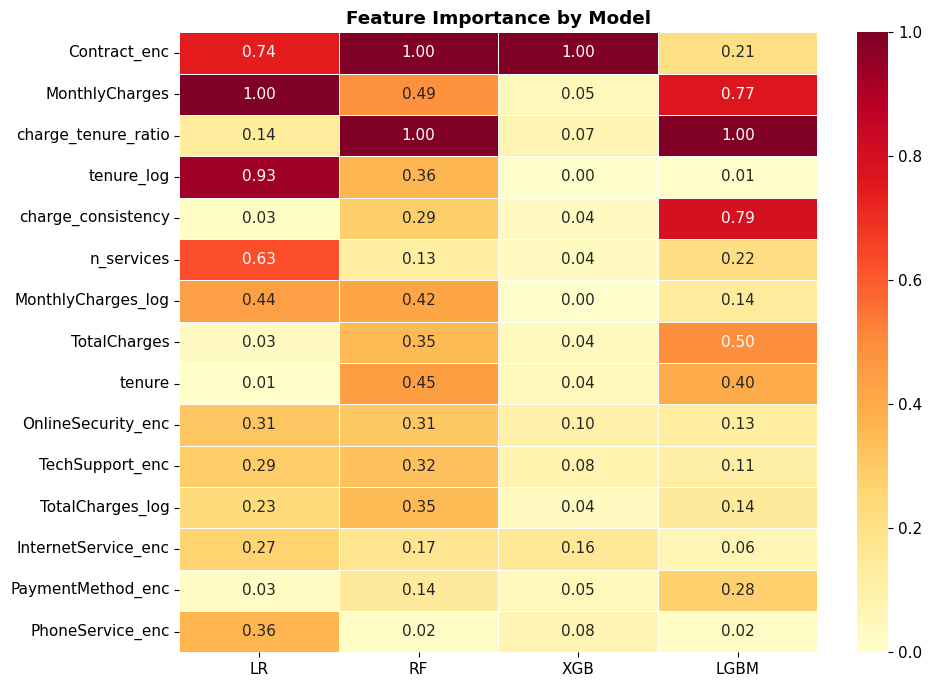

In [20]:
# Heatmap
top_n = min(15, len(feature_cols)); ti = np.argsort(ai)[::-1][:top_n]
hm = pd.DataFrame({n: [ni[n][i] for i in ti] for n in ni}, index=[feature_cols[i] for i in ti])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Feature Importance by Model', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Production Deployment Considerations

### Digital Service Retention Architecture

```
User Activity Data (myGov logins, transaction history, service usage)
    │
    ▼
Batch Risk Scoring (nightly)
    │
    ├── LOW RISK (< 0.2) ──► No action, monitor
    ├── MEDIUM RISK (0.2 - 0.5) ──► Automated nudge (email, in-app notification)
    │       └── "Did you know you can do X online?"
    ├── HIGH RISK (0.5 - 0.7) ──► Targeted outreach
    │       ├── Digital literacy support offer
    │       ├── Accessibility assessment
    │       └── Alternative channel suggestions (app vs web)
    └── VERY HIGH RISK (> 0.7) ──► Proactive human contact
            ├── Dedicated support call
            ├── In-person digital assistance (Service Centre)
            └── Vulnerability assessment
```

### Regulatory & Policy Framework

| Framework | Relevance |
|-----------|-----------|
| **Digital Experience Policy** | DTA mandate for user-centred design |
| **Digital Inclusion Strategy** | Ensuring no one is left behind |
| **Privacy Act 1988** | User data handling, APPs |
| **Disability Discrimination Act 1992** | WCAG 2.1 AA accessibility requirements |
| **APS Code of Conduct** | Public servant obligations |
| **Data and Digital Government Strategy 2030** | Digital transformation targets |

### Key Considerations

**Digital Inclusion, Not Just Efficiency:** The goal isn't just to reduce call centre costs — it's to ensure every Australian can access government services. Some users *should* use phone/in-person channels (elderly, disability, language barriers).

**Privacy:** User engagement data must comply with the Privacy Act's Australian Privacy Principles. Profiling for retention purposes must be proportionate and transparent.

**Channel Complementarity:** The model should recommend the *right* channel for each user, not force everyone online. Some interactions genuinely require human contact.

**A/B Testing Interventions:** Different retention interventions (email nudge vs in-app tutorial vs phone call) should be tested and measured. The model identifies *who* is at risk; the intervention strategy determines *how* to help.

---
## 9. Key Takeaways

In [21]:
print("=" * 70)
print("DIGITAL SERVICE ENGAGEMENT — KEY RESULTS")
print("=" * 70)
print(f"\n1. DATASET: {len(df):,} users, {churn_pct:.1f}% churn/disengagement rate")
print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:  {best_model[1]['pr_auc']:.4f}")
print(f"   ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"   F1:      {best_model[1]['f1']:.4f}")
print(f"\n3. MODEL COMPARISON (PR-AUC):")
for n in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    m = " ◄ BEST" if n == best_model[0] else ""
    print(f"   {n:<22} {results[n]['pr_auc']:.4f}{m}")
print(f"\n4. TOP DISENGAGEMENT DRIVERS:")
for i in range(min(5,len(tn))):
    print(f"   [{i+1}] {tn[i]} ({tv[i]:.3f})")
print(f"\n5. GOVERNMENT-SPECIFIC INSIGHTS:")
print(f"   • FP cost is very low in government — proactive outreach is harmless")
print(f"   • Lower thresholds are optimal — wide net with digital support")
print(f"   • Digital inclusion is the goal, not just cost reduction")
print(f"   • Channel complementarity — some users should use phone/in-person")
print(f"   • Accessibility (WCAG 2.1 AA) and language support reduce churn")
print(f"   • Privacy Act APPs apply to all user engagement profiling")
print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure)")
print(f"  [5] Visa Risk Scoring (Immigration & Border Security)")
print(f"  [6] Benefits Fraud Detection (Welfare Compliance)")
print(f"  [7] Tax Compliance Risk Scoring (Revenue Administration)")
print(f"  [8] Digital Service Engagement (Government Platforms) ← This notebook")
print(f"{'='*70}")

DIGITAL SERVICE ENGAGEMENT — KEY RESULTS

1. DATASET: 7,043 users, 26.5% churn/disengagement rate

2. BEST MODEL: Logistic Regression
   PR-AUC:  0.6659
   ROC-AUC: 0.8470
   F1:      0.6283

3. MODEL COMPARISON (PR-AUC):
   Logistic Regression    0.6659 ◄ BEST
   LightGBM               0.6559
   Random Forest          0.6473
   XGBoost                0.6377

4. TOP DISENGAGEMENT DRIVERS:
   [1] Contract_enc (0.739)
   [2] MonthlyCharges (0.576)
   [3] charge_tenure_ratio (0.552)
   [4] tenure_log (0.326)
   [5] charge_consistency (0.285)

5. GOVERNMENT-SPECIFIC INSIGHTS:
   • FP cost is very low in government — proactive outreach is harmless
   • Lower thresholds are optimal — wide net with digital support
   • Digital inclusion is the goal, not just cost reduction
   • Channel complementarity — some users should use phone/in-person
   • Accessibility (WCAG 2.1 AA) and language support reduce churn
   • Privacy Act APPs apply to all user engagement profiling

Notebook by Dean | Lead D